In [1]:
import numpy as np
import pandas as pd
from scipy import constants
from scipy import special as sp 
import os
import pickle
import subprocess
import matplotlib.pyplot as plt


# Encontrando as frequencias para os modos TM $_{0np}$

In [2]:
d = 0.276
R = 0.5202

f0np = lambda n, p: ((constants.c * np.sqrt((sp.jn_zeros(0, n)[n-1]/R)**2 + ((p * constants.pi)/d)**2)) / (2*constants.pi)) *1e-6 

In [3]:
def pairs(i, j):
    pares = []
    for x in range(1, i+1):
        for y in range(0, j+1):
            pares.append((x, y))
    return pares
pares = pairs(4, 4)

In [4]:
pares

[(1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4)]

In [5]:
modos = []
for f in pares:
    modos.append({"Modo":f, "Freq": f0np(f[0], f[1])})
modos

[{'Modo': (1, 0), 'Freq': np.float64(220.5738712710689)},
 {'Modo': (1, 1), 'Freq': np.float64(586.1850545064739)},
 {'Modo': (1, 2), 'Freq': np.float64(1108.3741130342735)},
 {'Modo': (1, 3), 'Freq': np.float64(1644.1695781277463)},
 {'Modo': (1, 4), 'Freq': np.float64(2183.578301713848)},
 {'Modo': (2, 0), 'Freq': np.float64(506.3090728589849)},
 {'Modo': (2, 1), 'Freq': np.float64(742.5018267308012)},
 {'Modo': (2, 2), 'Freq': np.float64(1198.411122702193)},
 {'Modo': (2, 3), 'Freq': np.float64(1706.1622567073127)},
 {'Modo': (2, 4), 'Freq': np.float64(2230.6300106219664)},
 {'Modo': (3, 0), 'Freq': np.float64(793.7316952445514)},
 {'Modo': (3, 1), 'Freq': np.float64(961.7536532163739)},
 {'Modo': (3, 2), 'Freq': np.float64(1345.306785009574)},
 {'Modo': (3, 3), 'Freq': np.float64(1812.3605527016564)},
 {'Modo': (3, 4), 'Freq': np.float64(2312.870807257469)},
 {'Modo': (4, 0), 'Freq': np.float64(1081.535577961678)},
 {'Modo': (4, 1), 'Freq': np.float64(1210.23935311828)},
 {'Modo': 

In [6]:
modos[15]["Freq"]

np.float64(1081.535577961678)

In [7]:
extend = {}
tipo = []
freq = []
for modo in modos:
    tipo.append(modo["Modo"])
    freq.append(modo["Freq"])

extend["Modes"] = tipo
extend["Ressonant Frequencies"] = freq

In [8]:
len(modos)

20

In [9]:
def gera_arquivo(boundarie, freq, mode):
    wb = ""
    if boundarie:
        wb = "PE"
    else:
        wb = "PM"
    code = f"""
    {freq} {wb}
    $reg kprob=1,
    kmethod=1,
    dx=0.1,
    dy=0.1,
    freq={freq},
    beta=1,
    norm=1,
    clength=13.8
    ezero=3260869.57,
    ezerot=3260869.57
    rmass=0.511,
    nbsup = 1,
    nbslo = 0,
    nbsrt = 1,
    nbslf = {boundarie},
    zctr=0$
    $po x=0, y=0$
    $po x=23.8, y=0$  
    $po x=23.8, y=3.5$
    $po x=13.8, y=3.5$
    $po x=11.3, y=3.5$
    $po nt=5, x0=11.3, y0=4.5, x=-0.573576436351046, y=0.8191520442889918, radius=1$
    $po x=13.458861149080837, y=7.232425439295934$
    $po nt=2, x0=13.0, y0=7.887747074727128, x=0.8, y=0, radius=0.8$
    $po x=13.8, y=34.0$
    $po nt=2, x0=13.9, y0=34.0, x=0, y=0.1, radius=0.1$
    $po x=17.8, y=34.1$
    $po x=17.8, y=35.1$
    $po x=13.9, y=35.1$
    $po nt=2, x0=13.9, y0=35.2, x=-0.1, y=0, radius=0.1$
    $po x=13.8, y=41.02$
    $po nt=2, x0=2.8000000000000007, y0=41.02, x=0, y=11, radius=11$
    $po x=0, y=52.02$
    $po x=0, y=0$
    """
    #with open(f"{mode} {wb}.af", "wt") as f:
        #f.write(code)
    return f"{mode} {wb}"


In [10]:
nomes = []
for modo in modos:
    
    if modo["Modo"][1] != 0:
        nome = gera_arquivo(0, modo["Freq"], f"{modo["Modo"]}")
        nomes.append(nome)
        nome = gera_arquivo(1, modo["Freq"], f"{modo["Modo"]}")
    else:
        nome = gera_arquivo(1, modo["Freq"], f"{modo["Modo"]}")
    nomes.append(nome)

In [11]:
nomes

['(1, 0) PE',
 '(1, 1) PM',
 '(1, 1) PE',
 '(1, 2) PM',
 '(1, 2) PE',
 '(1, 3) PM',
 '(1, 3) PE',
 '(1, 4) PM',
 '(1, 4) PE',
 '(2, 0) PE',
 '(2, 1) PM',
 '(2, 1) PE',
 '(2, 2) PM',
 '(2, 2) PE',
 '(2, 3) PM',
 '(2, 3) PE',
 '(2, 4) PM',
 '(2, 4) PE',
 '(3, 0) PE',
 '(3, 1) PM',
 '(3, 1) PE',
 '(3, 2) PM',
 '(3, 2) PE',
 '(3, 3) PM',
 '(3, 3) PE',
 '(3, 4) PM',
 '(3, 4) PE',
 '(4, 0) PE',
 '(4, 1) PM',
 '(4, 1) PE',
 '(4, 2) PM',
 '(4, 2) PE',
 '(4, 3) PM',
 '(4, 3) PE',
 '(4, 4) PM',
 '(4, 4) PE']

In [12]:
OUTPUT = []

In [23]:
resultados = {"Modes": [], "Ressonant Frequencies": [], "Q": [], "r/Q": []}
for nome in nomes:
    resultados["Modes"].append(nome)
    #subprocess.run([r"C:\LANL\AUTOFISH.EXE", f"{nome}.af"], check=True)
    #with open("OUTFIS.TXT", "r") as o:
    #    lines = o.readlines()
    #    for line in lines:
    #        if "Solution converged at the start" in line:
    #            OUTPUT.append(f"{nome} : Success")
    #        elif "Solution terminated at the maximum" in line:
    #            OUTPUT.append(f"{nome} : Failure")
    #    o.close()

In [24]:
for nome in nomes:
    with open(f"{nome}.SFO", "r") as f:
        lines = f.readlines()
        readed = False
        for line in lines:
            if "Frequency for T integrals" in line:
                resultados["Ressonant Frequencies"].append(float(line.split()[5]))
                readed = True
                continue
            elif not readed:
                continue
            if "Shunt impedance" in line:
                resultados["Q"].append(float(line.split()[2]))
                continue
            if "r/Q" in line:
                resultados["r/Q"].append(float(line.split()[2]))
                break

In [25]:
OUTPUT

[]

In [26]:
resultados

{'Modes': ['(1, 0) PE',
  '(1, 1) PM',
  '(1, 1) PE',
  '(1, 2) PM',
  '(1, 2) PE',
  '(1, 3) PM',
  '(1, 3) PE',
  '(1, 4) PM',
  '(1, 4) PE',
  '(2, 0) PE',
  '(2, 1) PM',
  '(2, 1) PE',
  '(2, 2) PM',
  '(2, 2) PE',
  '(2, 3) PM',
  '(2, 3) PE',
  '(2, 4) PM',
  '(2, 4) PE',
  '(3, 0) PE',
  '(3, 1) PM',
  '(3, 1) PE',
  '(3, 2) PM',
  '(3, 2) PE',
  '(3, 3) PM',
  '(3, 3) PE',
  '(3, 4) PM',
  '(3, 4) PE',
  '(4, 0) PE',
  '(4, 1) PM',
  '(4, 1) PE',
  '(4, 2) PM',
  '(4, 2) PE',
  '(4, 3) PM',
  '(4, 3) PE',
  '(4, 4) PM',
  '(4, 4) PE'],
 'Ressonant Frequencies': [224.6000157,
  602.0244508,
  508.7871031,
  602.0244509,
  1131.8364103,
  1681.2556797,
  1823.5403394,
  2256.4397247,
  2213.2867764,
  508.7871033,
  764.6620246,
  783.6651295,
  1205.6686035,
  1224.6959802,
  1681.2556776,
  1711.2948874,
  2256.4397725,
  2273.4716996,
  783.6651405,
  978.0565195,
  1131.8359621,
  1519.8195554,
  1328.4946371,
  1733.2892093,
  1823.5403394,
  2326.5565347,
  2213.286789,
  1

In [27]:
index = np.arange(0, 36)

In [28]:
dataframe = pd.DataFrame(resultados)
dataframe = dataframe.sort_values("Ressonant Frequencies")

In [29]:
dataframe.index = index

In [30]:
dataframe

,Modes,Ressonant Frequencies,Q,r/Q
0,"(1, 0) PE",224.600016,37054.7,93.488
1,"(1, 1) PE",508.787103,61918.2,56.573
2,"(2, 0) PE",508.787103,61918.0,56.573
3,"(1, 1) PM",602.024451,34005.3,4.024
4,"(1, 2) PM",602.024451,34005.3,4.024
5,"(2, 1) PM",764.662025,44267.9,19.162
6,"(2, 1) PE",783.665130,52421.8,17.321
7,"(3, 0) PE",783.665141,52414.9,17.318
8,"(3, 1) PM",978.056520,39096.5,17.952
9,"(4, 0) PE",1043.197666,36239.2,1.358


In [31]:
v1 = 0
for i in index:
    if dataframe["Ressonant Frequencies"][i] - v1 < 1:
        dataframe = dataframe.drop(i)
    else:
        v1 = dataframe["Ressonant Frequencies"][i]

In [32]:
index = np.arange(0, len(dataframe["Q"]))
dataframe.index = index

In [33]:
dataframe

,Modes,Ressonant Frequencies,Q,r/Q
0,"(1, 0) PE",224.600016,37054.7,93.488
1,"(1, 1) PE",508.787103,61918.2,56.573
2,"(1, 1) PM",602.024451,34005.3,4.024
3,"(2, 1) PM",764.662025,44267.9,19.162
4,"(2, 1) PE",783.665130,52421.8,17.321
5,"(3, 1) PM",978.056520,39096.5,17.952
6,"(4, 0) PE",1043.197666,36239.2,1.358
7,"(3, 1) PE",1131.835962,51334.0,1.168
8,"(4, 1) PM",1205.668603,23956.8,11.111
9,"(4, 1) PE",1224.695977,55401.4,2.684


In [34]:
re = lambda p, c: ((c-p)**2/p)**0.5

In [35]:

m1 = modos[0]["Freq"]
m2 = modos[5]["Freq"]
m3 = modos[10]["Freq"]
m4 = modos[15]["Freq"]
lista = np.array([m1, m2, m3, m4])

comp = np.array([dataframe["Ressonant Frequencies"][0], dataframe["Ressonant Frequencies"][1], dataframe["Ressonant Frequencies"][4], dataframe["Ressonant Frequencies"][6]])

In [36]:
re(lista, comp)

array([0.27108926, 0.11012825, 0.35730943, 1.16575706])

In [37]:
compara = {}
compara["Modes"] = dataframe["Modes"]
compara["Ressonant Frequencies"] = dataframe["Ressonant Frequencies"]


In [38]:
i = []
v = []
for modo in compara["Modes"]:
    i.append(f"{modo}")
for modo in compara["Ressonant Frequencies"]:
    v.append(modo)
for modo in extend["Modes"]:
    i.append(f"{modo}")
for modo in extend["Ressonant Frequencies"]:
    v.append(modo)
total = {"Mode": i, "Freq": v}
total = pd.DataFrame(total)

In [39]:
total = total.sort_values("Freq")
len(total)

44

In [40]:
import itertools
erro = [re(a, b) for a, b in itertools.pairwise(total["Freq"])]
erro



[0.2710892633408478,
 18.797319315187643,
 0.11012825229109248,
 3.431321557204272,
 0.6542161396770152,
 5.725314143653935,
 0.8132514956695358,
 0.6872105285129766,
 0.359597010833572,
 5.963883892530891,
 0.5256928184952002,
 2.0829239828528117,
 1.186984792033206,
 0.8160906493868453,
 0.7047239798299226,
 1.9788846438860694,
 0.20964425606130968,
 0.13163563562673652,
 0.41555762525356144,
 2.966041252990237,
 0.4612600776235797,
 4.757913549599424,
 0.3336615531785402,
 2.843894411699493,
 0.914614020797515,
 0.607431346256961,
 0.12425957145237955,
 0.5316773391898778,
 1.8992564097230809,
 0.2626099742977955,
 1.7599329380368038,
 1.3058805056531686,
 2.3799372488403034,
 2.7036288391721004,
 0.6357640542300317,
 0.3686474589362559,
 0.5464738980442462,
 0.35855281786242593,
 0.8263073379177396,
 0.2845720217212969,
 1.6722035086458078,
 0.39802682610842555,
 2.7740981938645346]

In [41]:
duplas = list()
vals = {"duplas" : [], "erro" : []}
for a, b in itertools.pairwise(total["Freq"]):
    duplas.append(f"{a}, {b}") 
for d in range(0,len(duplas), 2):
    print(f"{duplas[d]}: \t {erro[d]}")
    vals["duplas"].append(duplas[d])
    vals["erro"].append(erro[d])

220.5738712710689, 224.6000157: 	 0.2710892633408478
506.3090728589849, 508.7871031: 	 0.11012825229109248
586.1850545064739, 602.0244508: 	 0.6542161396770152
742.5018267308012, 764.6620246: 	 0.8132514956695358
783.6651295, 793.7316952445514: 	 0.359597010833572
961.7536532163739, 978.0565195: 	 0.5256928184952002
1043.1976658, 1081.535577961678: 	 1.186984792033206
1108.3741130342735, 1131.8359621: 	 0.7047239798299226
1198.411122702193, 1205.6686033: 	 0.20964425606130968
1210.23935311828, 1224.6959773: 	 0.41555762525356144
1328.4945383, 1345.306785009574: 	 0.4612600776235797
1519.8195554, 1532.8273053915457: 	 0.3336615531785402
1644.1695781277463, 1681.2556776: 	 0.914614020797515
1706.1622567073127, 1711.2948874: 	 0.12425957145237955
1733.2892093, 1812.3605527016564: 	 1.8992564097230809
1823.5403394, 1898.6946347: 	 1.7599329380368038
1955.597089216019, 2060.8429919: 	 2.3799372488403034
2183.578301713848, 2213.2867764: 	 0.6357640542300317
2230.6300106219664, 2256.4397247: 

In [42]:
erros_quadrados = np.array(vals["erro"])
raiz_media_erros_quadrados = (sum(erros_quadrados)/(len(erros_quadrados)-1))
raiz_media_erros_quadrados

np.float64(0.9323168783733251)

In [43]:
import statistics as sts

0.8899388384472648


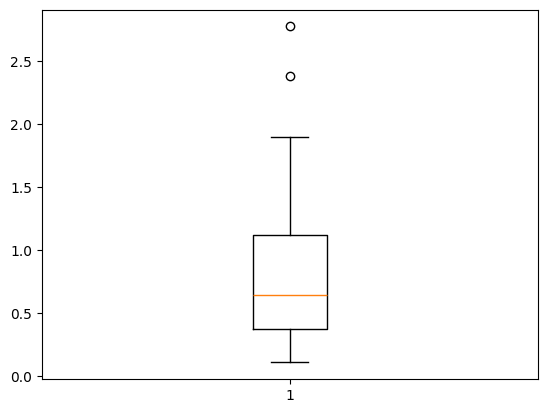

In [44]:
plt.boxplot(vals["erro"])
print(sts.mean(vals["erro"]))

In [45]:
perdidos = total.copy().sort_values("Freq")
index = np.arange(0, len(perdidos))
perdidos.index = index
print(perdidos)
for i in range(0, len(vals["erro"])):
    
    if vals["erro"][i] < 0.8:
        if i in perdidos.index: 
            perdidos = perdidos.drop(i)
        if i*2 !=0: 
            perdidos = perdidos.drop(i+1)
perdidos

         Mode         Freq
0      (1, 0)   220.573871
1   (1, 0) PE   224.600016
2      (2, 0)   506.309073
3   (1, 1) PE   508.787103
4      (1, 1)   586.185055
5   (1, 1) PM   602.024451
6      (2, 1)   742.501827
7   (2, 1) PM   764.662025
8   (2, 1) PE   783.665130
9      (3, 0)   793.731695
10     (3, 1)   961.753653
11  (3, 1) PM   978.056520
12  (4, 0) PE  1043.197666
13     (4, 0)  1081.535578
14     (1, 2)  1108.374113
15  (3, 1) PE  1131.835962
16     (2, 2)  1198.411123
17  (4, 1) PM  1205.668603
18     (4, 1)  1210.239353
19  (4, 1) PE  1224.695977
20  (4, 2) PE  1328.494538
21     (3, 2)  1345.306785
22  (3, 2) PM  1519.819555
23     (4, 2)  1532.827305
24     (1, 3)  1644.169578
25  (2, 3) PM  1681.255678
26     (2, 3)  1706.162257
27  (2, 3) PE  1711.294887
28  (3, 3) PM  1733.289209
29     (3, 3)  1812.360553
30  (1, 3) PE  1823.540339
31  (4, 3) PM  1898.694635
32     (4, 3)  1955.597089
33  (4, 3) PE  2060.842992
34     (1, 4)  2183.578302
35  (1, 4) PE  2213.286776
3

,Mode,Freq
15,"(3, 1) PE",1131.835962
16,"(2, 2)",1198.411123
20,"(4, 2) PE",1328.494538
21,"(3, 2)",1345.306785
22,"(3, 2) PM",1519.819555
23,"(4, 2)",1532.827305
24,"(1, 3)",1644.169578
25,"(2, 3) PM",1681.255678
26,"(2, 3)",1706.162257
27,"(2, 3) PE",1711.294887


In [46]:
p_resultados = {"Ressonant Frequencies": [], "Q": [], "r/Q": []}

for j in range(1, 13):
  with open(f"1({j}).SFO", "r") as f:
    lines = f.readlines()
    readed = False
    for line in lines:
      if "Frequency for T integrals" in line:
        p_resultados["Ressonant Frequencies"].append(float(line.split()[5]))
        readed = True
        continue
      elif not readed:
        continue
      if "Shunt impedance" in line:
        p_resultados["Q"].append(float(line.split()[2]))
        continue
      if "r/Q" in line:
        p_resultados["r/Q"].append(float(line.split()[2]))
        break
p_resultados = pd.DataFrame(p_resultados)

In [47]:
p_resultados

,Ressonant Frequencies,Q,r/Q
0,1483.527845,19389.6,4.054
1,1488.400000,14258.7,2.050
2,1978.162102,98434.5,2.671
3,2047.566792,38305.7,0.713
4,2091.241215,84038.9,0.936
5,1858.184123,30039.0,0.766
6,2499.900000,55654.6,1.075
7,2495.307225,85484.8,1.030
8,1978.162102,98434.5,2.671
9,1898.694697,70358.6,1.700


In [48]:
p_resultados = p_resultados.drop(2)

In [49]:
p_resultados.sort_values("Ressonant Frequencies")
p_resultados.index = np.arange(0, len(p_resultados["Q"]))

In [50]:
p_resultados["Modes"] = np.arange(0, len(p_resultados["Q"]))

In [51]:
p_resultados

,Ressonant Frequencies,Q,r/Q,Modes
0,1483.527845,19389.6,4.054,0
1,1488.400000,14258.7,2.050,1
2,2047.566792,38305.7,0.713,2
3,2091.241215,84038.9,0.936,3
4,1858.184123,30039.0,0.766,4
5,2499.900000,55654.6,1.075,5
6,2495.307225,85484.8,1.030,6
7,1978.162102,98434.5,2.671,7
8,1898.694697,70358.6,1.700,8
9,2047.566792,38305.7,0.713,9


In [52]:
resultado_final = pd.concat([p_resultados, dataframe])

In [53]:
resultado_final = resultado_final.sort_values(["Ressonant Frequencies"])
resultado_final.index = np.arange(0, len(resultado_final["Q"]))
resultado_final

,Ressonant Frequencies,Q,r/Q,Modes
0,224.600016,37054.7,93.488,"(1, 0) PE"
1,508.787103,61918.2,56.573,"(1, 1) PE"
2,602.024451,34005.3,4.024,"(1, 1) PM"
3,764.662025,44267.9,19.162,"(2, 1) PM"
4,783.665130,52421.8,17.321,"(2, 1) PE"
5,978.056520,39096.5,17.952,"(3, 1) PM"
6,1043.197666,36239.2,1.358,"(4, 0) PE"
7,1131.835962,51334.0,1.168,"(3, 1) PE"
8,1205.668603,23956.8,11.111,"(4, 1) PM"
9,1224.695977,55401.4,2.684,"(4, 1) PE"


## Fazendo a curva de impedâncias

In [54]:
resultado_final["r"] = (np.array(resultado_final["Q"]) * np.array(resultado_final["r/Q"]))
resultado_final

,Ressonant Frequencies,Q,r/Q,Modes,r
0,224.600016,37054.7,93.488,"(1, 0) PE",3.464170e+06
1,508.787103,61918.2,56.573,"(1, 1) PE",3.502898e+06
2,602.024451,34005.3,4.024,"(1, 1) PM",1.368373e+05
3,764.662025,44267.9,19.162,"(2, 1) PM",8.482615e+05
4,783.665130,52421.8,17.321,"(2, 1) PE",9.079980e+05
5,978.056520,39096.5,17.952,"(3, 1) PM",7.018604e+05
6,1043.197666,36239.2,1.358,"(4, 0) PE",4.921283e+04
7,1131.835962,51334.0,1.168,"(3, 1) PE",5.995811e+04
8,1205.668603,23956.8,11.111,"(4, 1) PM",2.661840e+05
9,1224.695977,55401.4,2.684,"(4, 1) PE",1.486974e+05


In [55]:
f = np.linspace(0.1, 3000, int(1e6))
len(f)

1000000

In [56]:
Z = lambda wi: abs((0.5*resultado_final["r"][wi])/(1 + (resultado_final["Q"][wi]*1j)*(((2*np.pi * f)/(2*np.pi *resultado_final["Ressonant Frequencies"][wi])) - ((2*np.pi *resultado_final["Ressonant Frequencies"][wi])/f))))

In [57]:
Z(3)

array([1.99416666e-04, 2.05398972e-04, 2.11381279e-04, ...,
       4.12656377e+00, 4.12655395e+00, 4.12654413e+00], shape=(1000000,))

In [58]:
distribution = []
for x in range(0, 33):
    
    distribution.append(np.array(Z(x)))
curva = sum(distribution)

In [59]:
frq = list(f)

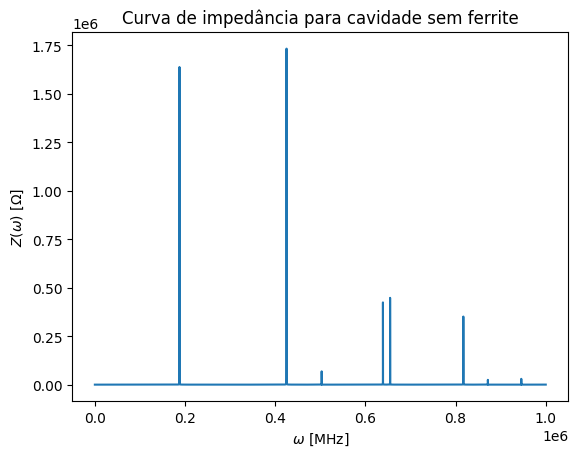

In [60]:
plt.plot(curva)
plt.title("Curva de impedância para cavidade sem ferrite")
plt.xlabel(r"$\omega $ [MHz]")
plt.ylabel(r"$Z(\omega) $ [$\Omega$]")

plt.show()